### **Visualization Geospatial Analysis**

#### **SETUP & DATA LOADING**

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import matplotlib.cm as cm
from shapely import wkt


In [2]:

# ---- Paths ----
ROOT           = Path().resolve().parent
GEOCODED_FILE  = ROOT / "data" / "geocoded_output" / "geocoded_output.gpkg"
COUNTIES_SHP   = ROOT / "tl_2024_us_county" / "tl_2024_us_county.shp"

# ---- Settings ----
KANSAS_FIPS    = "20"
CRS_GEOGRAPHIC = "EPSG:4326"
CRS_PROJECTED  = "EPSG:32614"   # UTM Zone 14N — Kansas


In [3]:
# Loading geocoded output from pipeline
bwa_gdf = gpd.read_file(GEOCODED_FILE)
bwa_gdf = bwa_gdf.to_crs(epsg=4326)

# Restoring buffer geometry from WKT string back to geometry
# Step 1: Parse WKT to Shapely geometries
bwa_gdf["buffer_geometry"] = bwa_gdf["buffer_geometry"].apply(wkt.loads)

# Step 2: Convert to GeoSeries so GeoPandas recognizes it as geometry
# bwa_gdf["buffer_geometry"] = gpd.GeoSeries(bwa_gdf["buffer_geometry"], crs=bwa_gdf.crs)
bwa_gdf["buffer_geometry"] = gpd.GeoSeries(bwa_gdf["buffer_geometry"], crs=CRS_PROJECTED)

# # print(f"Loaded {len(bwa_gdf)} BWA records")
bwa_gdf.head(2)

,Advisory_Notice_URL,Federal_ID,PWS_Name,PWS_Type,Issues_Date,Rescinded_Date,Advisory_Context,Advisory_Reason,Advisory_Category,Year,...,Population_Served,District,City,County,No._of_Violations,county_clean,lat,lon,buffer_geometry,geometry
0,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,"QUENEMO, CITY OF",Community water system,2024-02-28,2024-03-15,KDHE officials issued the advisory because of ...,line break,infrastructure_failure,2024,...,287,NE,QUENEMO,Osage,12,OSAGE,38.5797331,-95.5269256,"POLYGON ((812552.115 4275863.06, 812503.962 42...",POINT (-95.52693 38.57973)
1,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,"QUENEMO, CITY OF",Community water system,2024-03-05,2024-03-15,KDHE officials issued the advisory because of ...,low pressure,infrastructure_failure,2024,...,287,NE,QUENEMO,Osage,12,OSAGE,38.5797331,-95.5269256,"POLYGON ((812552.115 4275863.06, 812503.962 42...",POINT (-95.52693 38.57973)


In [4]:
print(bwa_gdf["PWS_Type"].unique())

<StringArray>
['Community water system', 'Transient non-community system']
Length: 2, dtype: str


In [5]:
bwa_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Advisory_Notice_URL  265 non-null    str           
 1   Federal_ID           265 non-null    str           
 2   PWS_Name             265 non-null    str           
 3   PWS_Type             265 non-null    str           
 4   Issues_Date          265 non-null    datetime64[ms]
 5   Rescinded_Date       265 non-null    datetime64[ms]
 6   Advisory_Context     265 non-null    str           
 7   Advisory_Reason      265 non-null    str           
 8   Advisory_Category    265 non-null    str           
 9   Year                 265 non-null    int64         
 10  Advisory_Duration    265 non-null    int64         
 11  Population_Served    265 non-null    str           
 12  District             230 non-null    str           
 13  City                 265 no

In [6]:
# # BEFORE apply(wkt.loads)
# print(type(bwa_gdf['buffer_geometry'].iloc[0]))  # <class 'str'>
# print(bwa_gdf['buffer_geometry'].dtype)          # object

# # AFTER both steps
# print(type(bwa_gdf['buffer_geometry'].iloc[0]))  # <class 'shapely.geometry.polygon.Polygon'>
# print(bwa_gdf['buffer_geometry'].dtype)          # geometry

In [7]:
# Load Kansas counties
us_counties = gpd.read_file(COUNTIES_SHP).to_crs(CRS_GEOGRAPHIC)
ks_counties = us_counties[us_counties["STATEFP"] == KANSAS_FIPS].copy()

print(f"Loaded {len(bwa_gdf)} BWA records across {len(ks_counties)} Kansas counties")

Loaded 265 BWA records across 105 Kansas counties


In [8]:
print(bwa_gdf["County"].unique()[:5])
# → ['Osage County', 'Greenwood County', 'Marion County' ...]

print(bwa_gdf["county_clean"].unique()[:5])
# → ['OSAGE', 'GREENWOOD', 'MARION' ...]

print(ks_counties["NAME"].unique()[:5])
# → ['Osage', 'Greenwood', 'Marion' ...]

<StringArray>
['Osage', 'Greenwood', 'Marion', 'Ellsworth', 'Barton']
Length: 5, dtype: str
<StringArray>
['OSAGE', 'GREENWOOD', 'MARION', 'ELLSWORTH', 'BARTON']
Length: 5, dtype: str
<StringArray>
['Greenwood', 'Doniphan', 'Republic', 'Decatur', 'Phillips']
Length: 5, dtype: str


### **DATA CLEANING & PREPARATION**

In [9]:
# To clean population to numeric
bwa_gdf['Population_Served'] = (
    bwa_gdf['Population_Served']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(float)
)

# Ensuring coordinate fields are numeric
bwa_gdf['lat'] = bwa_gdf['lat'].astype(float)
bwa_gdf['lon'] = bwa_gdf['lon'].astype(float)

print("Data cleaning complete")
print(bwa_gdf[['PWS_Name', 'County', 'Population_Served']].head())

Data cleaning complete
              PWS_Name     County  Population_Served
0     QUENEMO, CITY OF      Osage              287.0
1     QUENEMO, CITY OF      Osage              287.0
2  FALL RIVER, CITY OF  Greenwood              129.0
3     PEABODY, CITY OF     Marion              932.0
4   KANOPOLIS, CITY OF  Ellsworth              453.0


#### **Visualizing Advisories Per County**
COUNTY CHOROPLETH — Administrative Patterns

In [10]:
# Count advisories per county
county_counts = bwa_gdf["County"].value_counts().reset_index()
county_counts.columns = ["NAME", "bwa_count"]

ks_map = ks_counties.merge(county_counts, on="NAME", how="left")
ks_map["bwa_count"] = ks_map["bwa_count"].fillna(0)


c:\Users\aarun\anaconda3\envs\geospatial_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\aarun\anaconda3\envs\geospatial_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


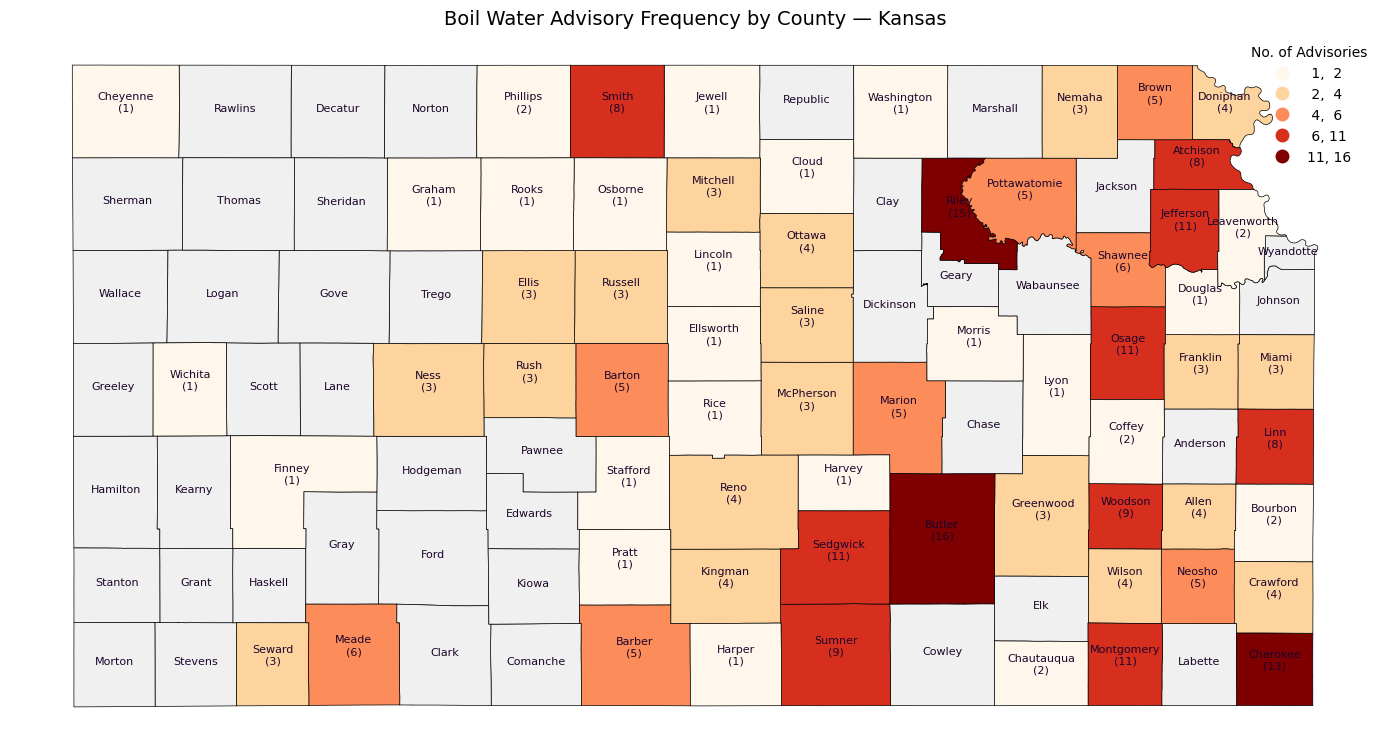

In [11]:
fig, ax = plt.subplots(figsize=(14, 9))

# Zero counties in gray first
ks_map[ks_map["bwa_count"] == 0].plot(
    ax=ax, color="#f0f0f0", edgecolor="black", linewidth=0.5
)
ks_map[ks_map["bwa_count"] > 0].plot(
    ax=ax,
    column="bwa_count",
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    scheme="NaturalBreaks",
    k=5,
    legend_kwds={"title": "No. of Advisories", "fmt": "{:.0f}", "frameon": False}
)
for _, row in ks_map.iterrows():
    ax.annotate(
        f"{row['NAME']}\n({int(row['bwa_count'])})" if row["bwa_count"] > 0 else row["NAME"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=8, ha="center", color="#1b042a"
    )

ax.set_title("Boil Water Advisory Frequency by County — Kansas", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### **Visualizing Adviosry plot by population size in all the counties**
SIMPLE POINT MAP — BWA Locations

In [12]:
bwa_gdf["Population_Served"].max()

np.float64(35126.0)

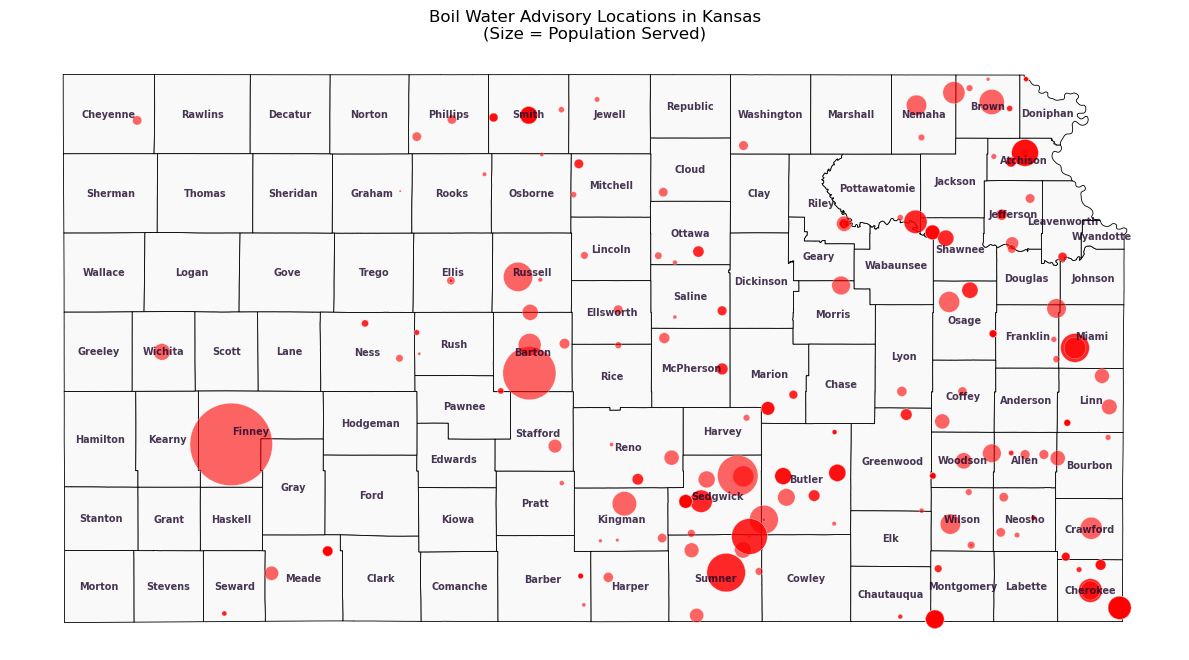

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

# Base layer as counties map
ks_counties.plot(ax=ax, color="#f9f9f9", edgecolor="black", linewidth=0.6)

# Simple points — all same color, sized by population
bwa_gdf.plot(
    ax=ax,
    color='red',
    markersize=bwa_gdf["Population_Served"].clip(upper=bwa_gdf["Population_Served"].max()) / 10,
    alpha=0.6,
    edgecolor='white',
    linewidth=0.3
)
# ---- ADD COUNTY NAME LABELS (at centroids) ----
for _, row in ks_counties.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["NAME"],
        xy=(centroid.x, centroid.y),
        fontsize=7,
        ha="center",
        va="center",
        color="#1b042a",
        alpha=0.8,
        fontweight='bold'
    )

ax.set_title("Boil Water Advisory Locations in Kansas\n(Size = Population Served)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()


#### **Visualizing Adviosry plot by population size in all the counties with City/County Labels**
SIMPLE POINT MAP — BWA Locations with City/County Labels

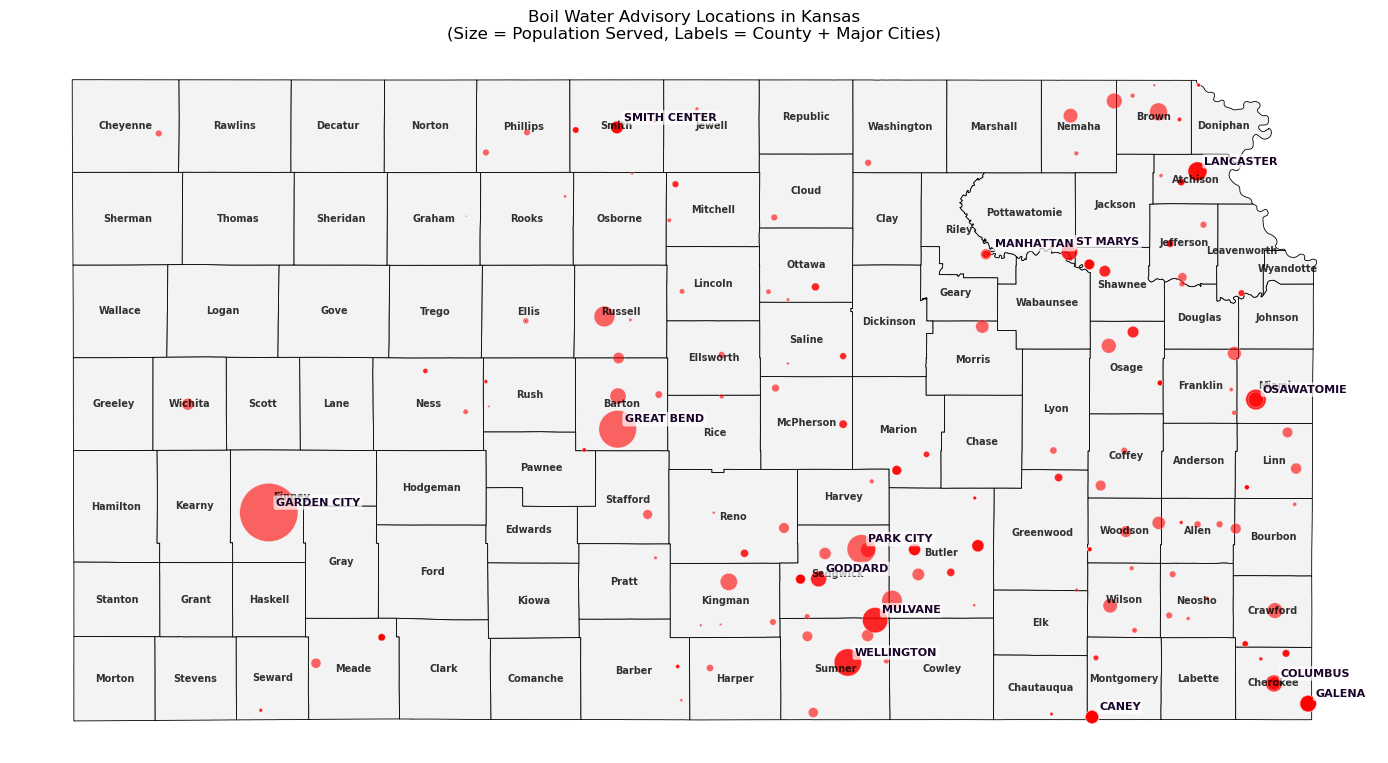

In [14]:
fig, ax = plt.subplots(figsize=(14, 10))

# Base layer
ks_counties.plot(ax=ax, color="#f3f3f3", edgecolor="black", linewidth=0.6)

# Simple points — all same color, sized by population
bwa_gdf.plot(
    ax=ax,
    color='red',
    markersize=bwa_gdf["Population_Served"].clip(upper=bwa_gdf["Population_Served"].max()) / 20,
    alpha=0.6,
    edgecolor='white',
    linewidth=0.3
)

# ---- ADD COUNTY NAME LABELS (at centroids) ----
for _, row in ks_counties.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["NAME"],
        xy=(centroid.x, centroid.y),
        fontsize=7,
        ha="center",
        va="center",
        color="black",
        alpha=0.8,
        fontweight='bold'
    )

# ---- ADD CITY LABELS (from BWA data) ----
# Get unique cities with their coordinates (use first occurrence)
city_coords = bwa_gdf.groupby('City').agg({
    'lon': 'first',
    'lat': 'first',
    'Population_Served': 'sum'  # Sum population for label sizing
}).reset_index()

# Only label larger cities (population > 5000) to avoid clutter
major_cities = city_coords[city_coords['Population_Served'] > 5000]

for _, row in major_cities.iterrows():
    ax.annotate(
        row["City"],
        xy=(row["lon"], row["lat"]),
        xytext=(5, 5),  # Offseting from the spot slightly
        textcoords='offset points',
        fontsize=8,
        ha="left",
        color="#1b042a",
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                  edgecolor='none', alpha=0.7)  # Light background for readability
    )

ax.set_title("Boil Water Advisory Locations in Kansas\n(Size = Population Served, Labels = County + Major Cities)", 
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### **Visualization on time basis**
TEMPORAL ANALYSIS — When Do Advisories Occur?

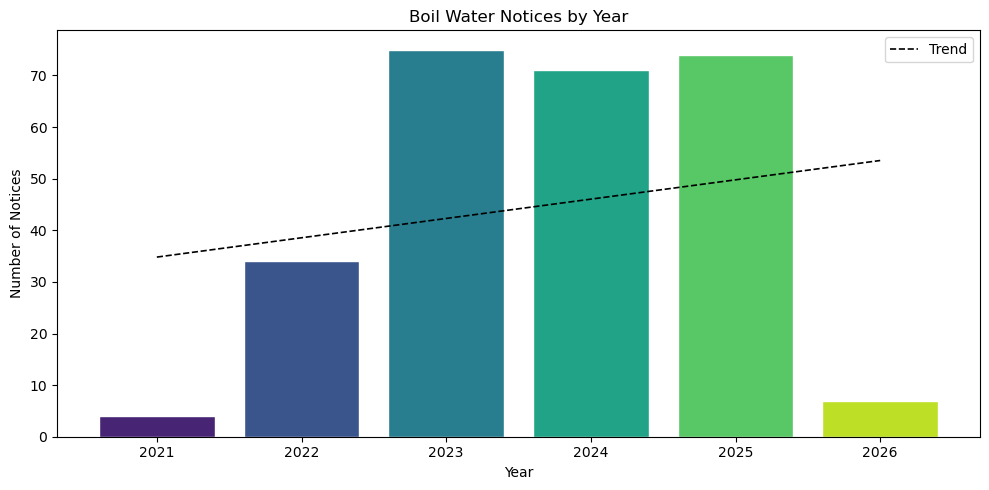

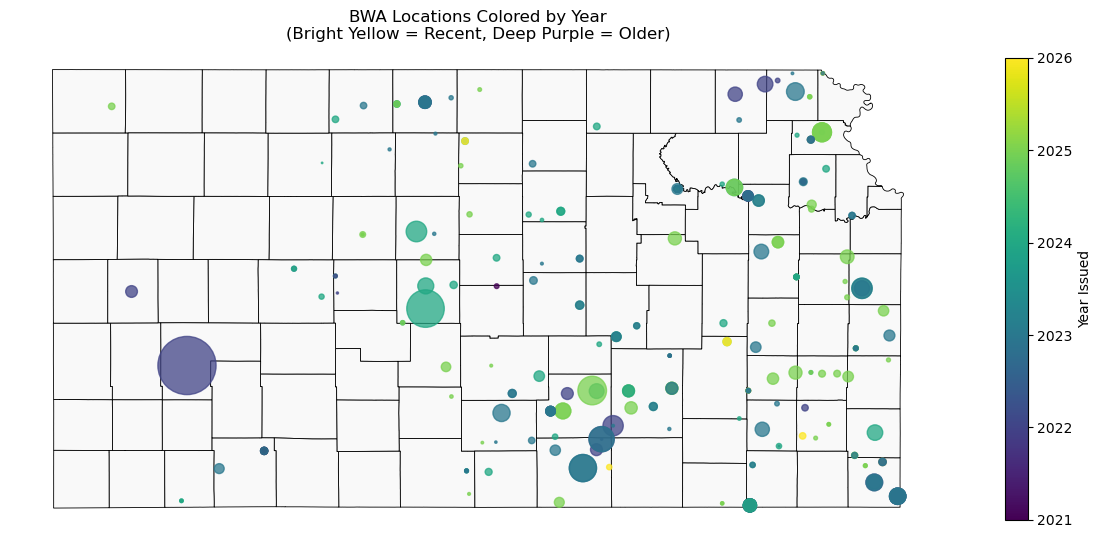

In [15]:
# ---- Bar Chart by Year ----
year_counts = bwa_gdf["Year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
# colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(year_counts)))
colors = cm.viridis(np.linspace(0.1, 0.9, len(year_counts)))

bars = ax.bar(year_counts.index, year_counts.values, color=colors, edgecolor="white")

# To plot trend line
z = np.polyfit(year_counts.index, year_counts.values, 1)
p = np.poly1d(z)
ax.plot(year_counts.index, p(year_counts.index), "k--", linewidth=1.2, label="Trend")

ax.set_title("Boil Water Notices by Year", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Notices")
ax.legend()
plt.tight_layout()
plt.show()

# ---- Point Map Colored by Year ----
fig, ax = plt.subplots(figsize=(12, 8))

ks_counties.plot(ax=ax, color="#f9f9f9", edgecolor="black", linewidth=0.6)

bwa_gdf.plot(
    ax=ax,
    column="Year",
    # cmap="RdYlGn_r",
    cmap="viridis",
    markersize=bwa_gdf["Population_Served"].clip(upper=bwa_gdf["Population_Served"].max()) / 20,
    alpha=0.75,
    legend=True,
    legend_kwds={"label": "Year Issued", "shrink": 0.6}
)

ax.set_title("BWA Locations Colored by Year\n(Bright Yellow = Recent, Deep Purple = Older)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### **Visualization — cause-type spatial clustering:**

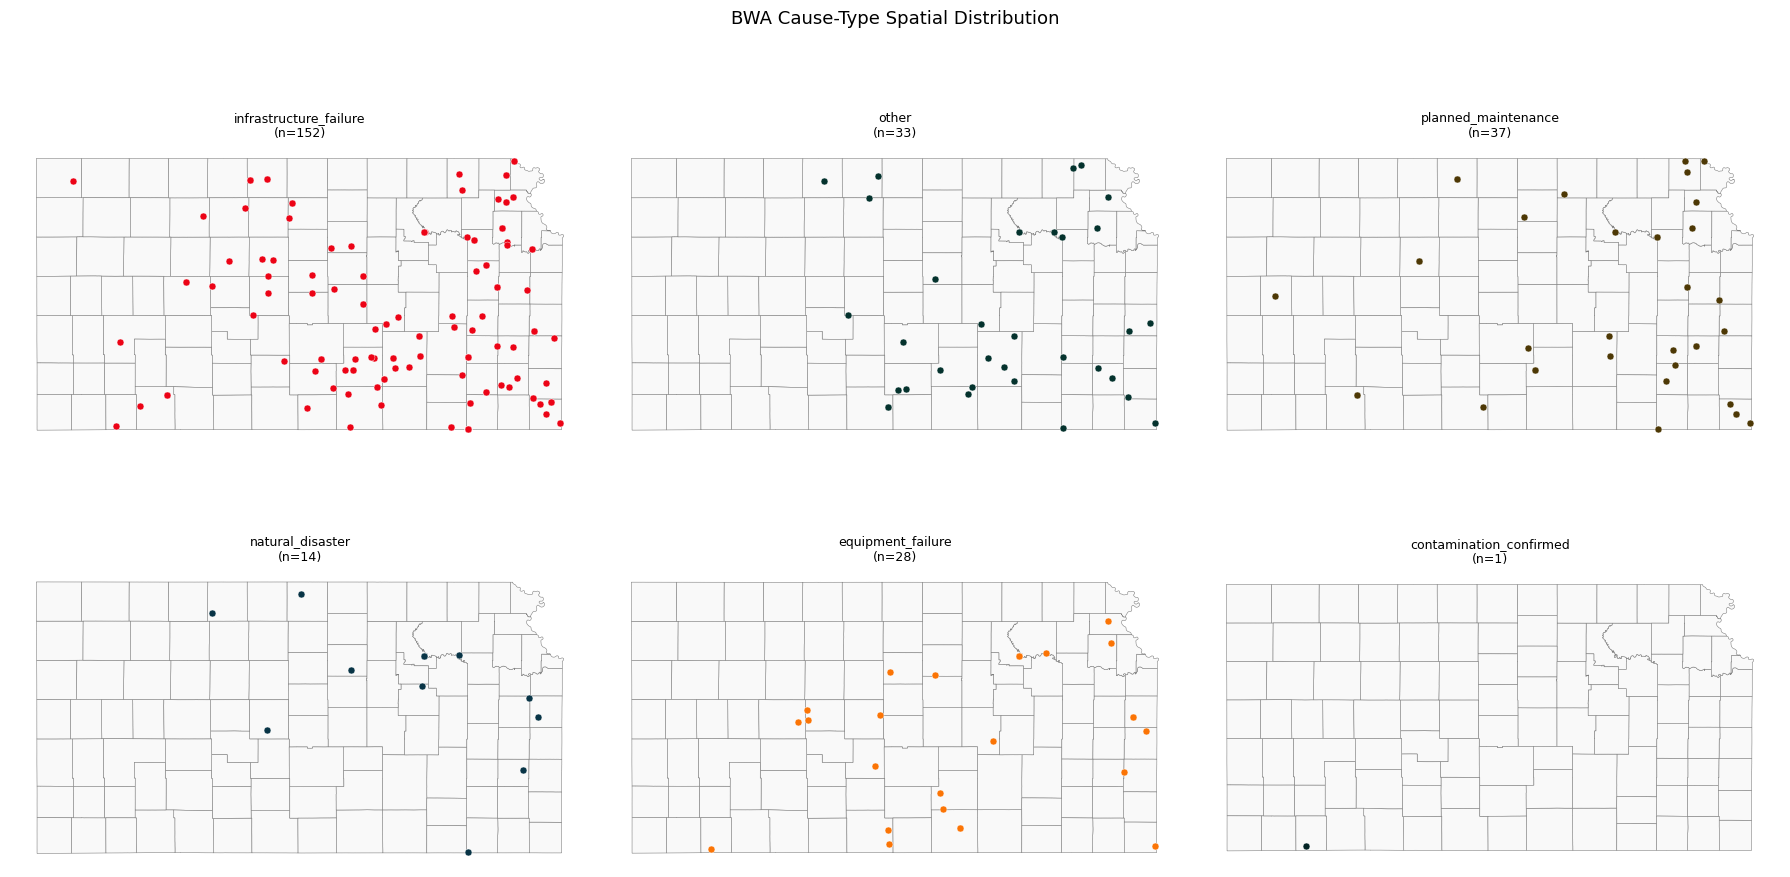

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

categories = bwa_gdf["Advisory_Category"].unique()
colors = ["#ec0316","#04322d","#4d3805","#083446","#fb7405","#032425"]

for i, cat in enumerate(categories):
    ax = axes[i]
    subset = bwa_gdf[bwa_gdf["Advisory_Category"] == cat]
    ks_counties.plot(ax=ax, color="#f9f9f9", edgecolor="gray", linewidth=0.4)
    subset.plot(ax=ax, color=colors[i % len(colors)],
                markersize=25, alpha=1, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{cat}\n(n={len(subset)})", fontsize=9)
    ax.set_axis_off()

# Hide unused subplots
for j in range(len(categories), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("BWA Cause-Type Spatial Distribution", fontsize=13)
plt.tight_layout()
plt.show()

#### **Visualization rural vs. urban by PWS_Type**

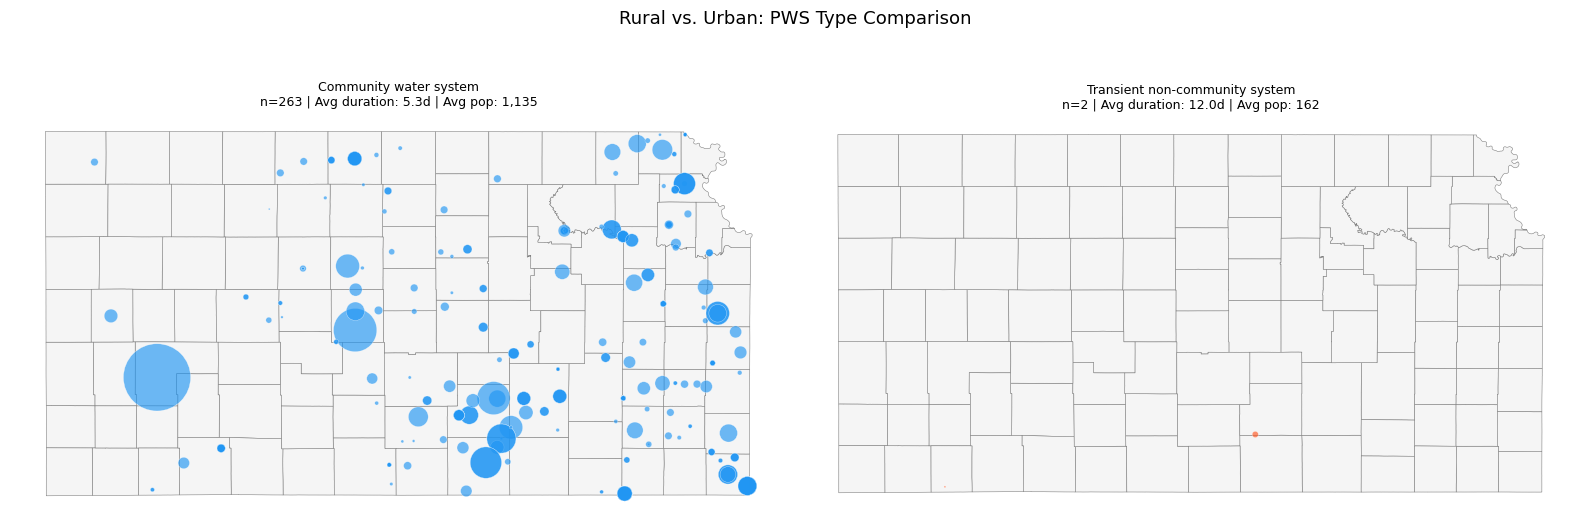

              Advisory_Duration  No._of_Violations  Population_Served
has_district                                                         
False                   4.00000          45.485714         911.057143
True                    5.53913          36.847826        1160.982609


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pws_types = bwa_gdf["PWS_Type"].unique()
type_colors = {"Community water system": "#2196F3",
               "Transient non-community system": "#FF5722"}

for ax, ptype in zip(axes, pws_types):
    subset = bwa_gdf[bwa_gdf["PWS_Type"] == ptype]
    ks_counties.plot(ax=ax, color="#f5f5f5", edgecolor="gray", linewidth=0.4)
    subset.plot(ax=ax,
                color=type_colors.get(ptype, "purple"),
                markersize=subset["Population_Served"] / 15,
                alpha=0.65, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{ptype}\nn={len(subset)} | "
                 f"Avg duration: {subset['Advisory_Duration'].mean():.1f}d | "
                 f"Avg pop: {subset['Population_Served'].mean():,.0f}",
                 fontsize=9)
    ax.set_axis_off()

plt.suptitle("Rural vs. Urban: PWS Type Comparison", fontsize=13)
plt.tight_layout()
plt.show()

# District null = likely rural signal
bwa_gdf["has_district"] = bwa_gdf["District"].notna()
print(bwa_gdf.groupby("has_district")[["Advisory_Duration","No._of_Violations","Population_Served"]].mean())

#### **Visulization of population and advisory**
DISTRIBUTION ANALYSIS — Population & Duration 

C:\Users\aarun\AppData\Local\Temp\ipykernel_14980\898622237.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_year, labels=years, patch_artist=True,


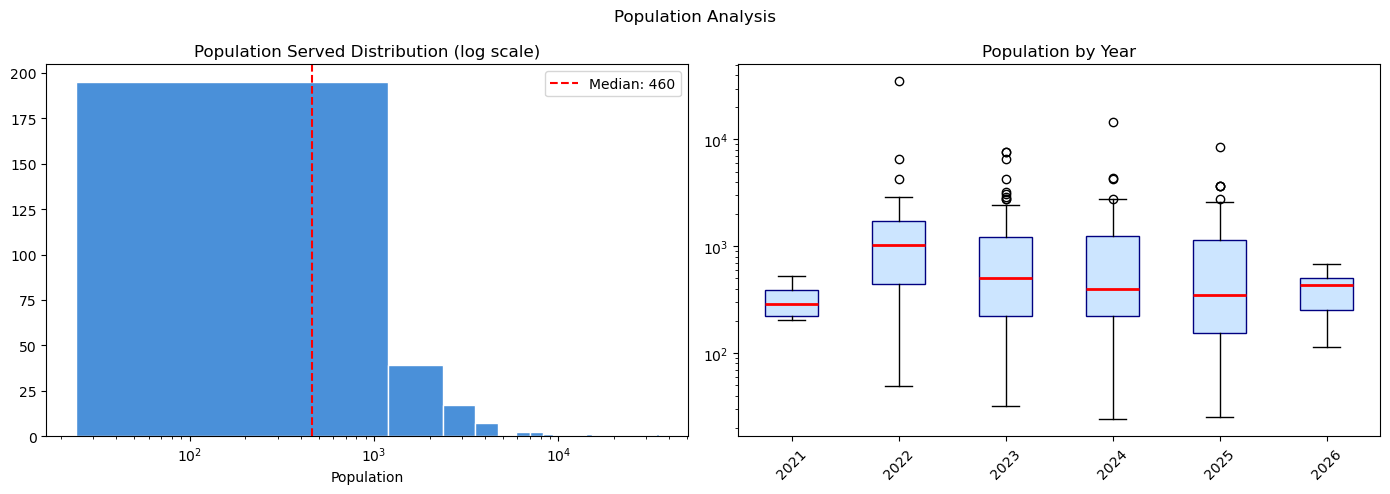

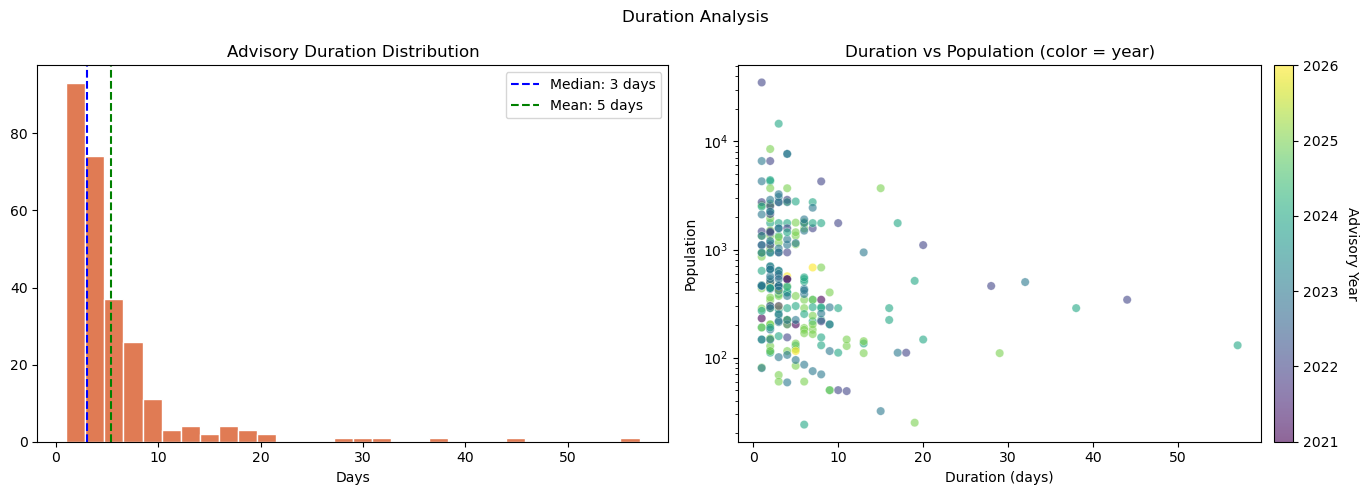

In [18]:
# ---- Population Distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pop = bwa_gdf["Population_Served"].dropna()

axes[0].hist(pop, bins=30, color="#4a90d9", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Population Served Distribution (log scale)")
axes[0].set_xlabel("Population")
axes[0].axvline(pop.median(), color="red", linestyle="--", label=f"Median: {int(pop.median()):,}")
axes[0].legend()

# Boxplot by year
years = sorted(bwa_gdf["Year"].unique())
data_by_year = [bwa_gdf[bwa_gdf["Year"] == y]["Population_Served"].dropna() for y in years]

axes[1].boxplot(data_by_year, labels=years, patch_artist=True,
                boxprops=dict(facecolor="#cce5ff", color="navy"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Population by Year")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Population Analysis", fontsize=12)
plt.tight_layout()
plt.show()

# ---- Duration Analysis ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dur = bwa_gdf["Advisory_Duration"].dropna()

axes[0].hist(dur, bins=30, color="#e07b54", edgecolor="white")
axes[0].axvline(dur.median(), color="blue", linestyle="--", label=f"Median: {int(dur.median())} days")
axes[0].axvline(dur.mean(), color="green", linestyle="--", label=f"Mean: {int(dur.mean())} days")
axes[0].set_title("Advisory Duration Distribution")
axes[0].set_xlabel("Days")
axes[0].legend()

axes[1].scatter(
    dur, 
    bwa_gdf["Population_Served"],
    c=bwa_gdf["Year"],
    cmap="viridis",
    alpha=0.6, edgecolors="white", linewidth=0.3
)
# Add a colorbar with label
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1], pad=0.02)
cbar.set_label("Advisory Year", rotation=270, labelpad=15)


axes[1].set_title("Duration vs Population (color = year)")
axes[1].set_xlabel("Duration (days)")
axes[1].set_ylabel("Population")
axes[1].set_yscale("log")

plt.suptitle("Duration Analysis", fontsize=12)
plt.tight_layout()
plt.show()

#### **SEVERITY INDEX — Composite Risk Metric**

In [19]:
bwa_gdf['severity_index'] = (
    bwa_gdf['Advisory_Duration'] * 
    bwa_gdf['Population_Served'] * 
    bwa_gdf['No._of_Violations']
)

print(f"Severity index range: {bwa_gdf['severity_index'].min():,.0f} to {bwa_gdf['severity_index'].max():,.0f}")
print("\nTop 5 highest severity advisories:")
print(bwa_gdf.nlargest(5, 'severity_index')[['PWS_Name', 'County', 'severity_index']])

# County-level aggregation
county_severity = bwa_gdf.groupby('County').agg({
    'Federal_ID': 'nunique',
    'Advisory_Duration': 'sum',
    'Population_Served': 'sum',
    'No._of_Violations': 'sum',
    'severity_index': 'sum'
})
county_severity.columns = ['systems', 'total_days', 'total_pop', 'total_violations', 'total_severity']
county_severity = county_severity.sort_values('total_severity', ascending=False)

print("\nTop 5 counties by total severity:")
print(county_severity.head())

Severity index range: 560 to 3,283,720

Top 5 highest severity advisories:
                PWS_Name      County  severity_index
45        CANEY, CITY OF  Montgomery       3283720.0
169       CANEY, CITY OF  Montgomery       1931600.0
242  WELLINGTON, CITY OF      Sumner       1808704.0
243  WELLINGTON, CITY OF      Sumner       1808704.0
39        CANEY, CITY OF  Montgomery       1545280.0

Top 5 counties by total severity:
            systems  total_days  total_pop  total_violations  total_severity
County                                                                      
Montgomery        2          80    16388.0              1450      13310800.0
Sumner            7          31    32443.0               347       4492762.0
Miami             2          10    10995.0               188       1823210.0
Cherokee          5          43    23377.0               274       1741374.0
Linn              3          50     3695.0               735       1695967.0


#### **WEIGHTED HOTSPOT ANALYSIS (KDE)**

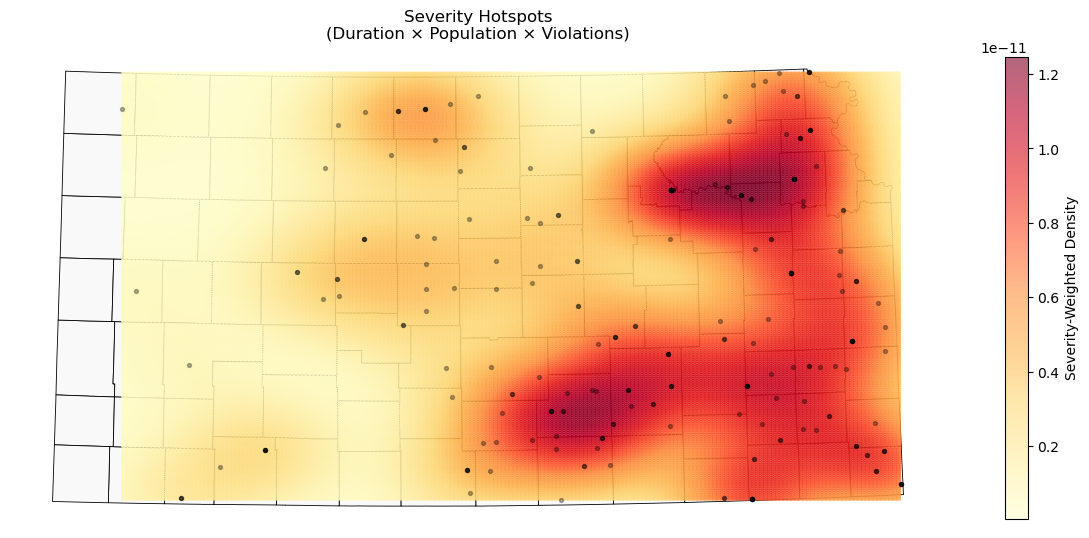

In [20]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 8))

ks_counties.to_crs(CRS_PROJECTED).plot(ax=ax, color="#f9f9f9", edgecolor="black", linewidth=0.6)

# To Project data for accurate distance
bwa_proj = bwa_gdf.to_crs(CRS_PROJECTED)

# log-transform severity index for better visualization
bwa_proj['severity_index_log'] = np.log1p(bwa_proj['severity_index'])


# Weighted KDE
x_coord = bwa_proj.geometry.x.values
y_coord = bwa_proj.geometry.y.values
coords = np.vstack([x_coord, y_coord])

# coords = np.vstack([bwa_proj.geometry.x, bwa_proj.geometry.y])
kde = gaussian_kde(coords, weights=bwa_proj['severity_index_log'], bw_method=0.3)

# Grid
xmin, ymin, xmax, ymax = bwa_proj.total_bounds
xi, yi = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)

# Plot
im = ax.pcolormesh(xi, yi, zi, shading='gouraud', cmap='YlOrRd', alpha=0.6)
plt.colorbar(im, ax=ax, label='Severity-Weighted Density', shrink=0.6)

bwa_proj.plot(ax=ax, color='black', markersize=8, alpha=0.3)

ax.set_title("Severity Hotspots\n(Duration × Population × Violations)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### **BUFFER OVERLAP ANALYSIS BETWEEN PWSs — CONCURRENT ADVISORIES**

Found 3 concurrent overlapping zones
Total overlap area: 753.3 km²


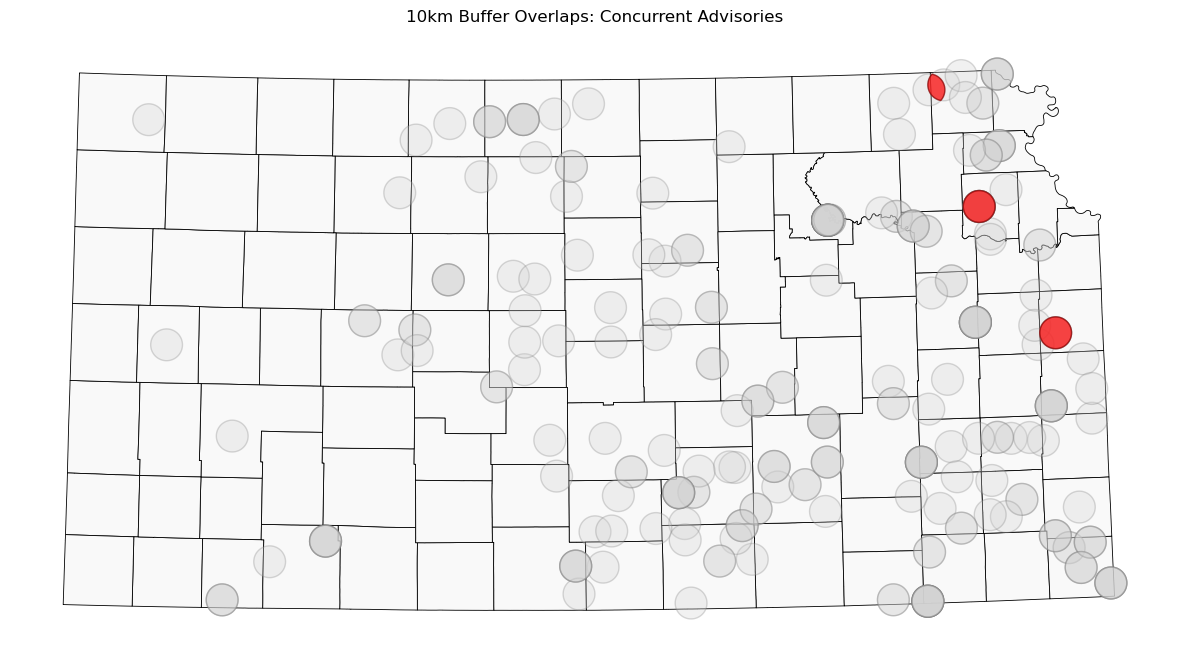

In [21]:
bwa_proj = bwa_gdf.to_crs(CRS_PROJECTED).copy()
bwa_buffers = bwa_proj.set_geometry('buffer_geometry')

overlaps = []

for i, row1 in bwa_buffers.iterrows():
    for j, row2 in bwa_buffers.iloc[i+1:].iterrows():
        # SKIPING the same PWS - only analyze cross-system overlaps
        if row1['PWS_Name'] == row2['PWS_Name']:
            continue            
        if row1['buffer_geometry'].intersects(row2['buffer_geometry']):
            concurrent = (
                row1['Issues_Date'] <= row2['Rescinded_Date'] and 
                row2['Issues_Date'] <= row1['Rescinded_Date']
            )
            if concurrent:
                intersection = row1['buffer_geometry'].intersection(row2['buffer_geometry'])
                overlaps.append({
                    'pws_1': row1['PWS_Name'],
                    'pws_2': row2['PWS_Name'],
                    'geometry': intersection,
                    'overlap_area_km2': intersection.area / 1e6,
                    'concurrent_days': (min(row1['Rescinded_Date'], row2['Rescinded_Date']) - 
                                       max(row1['Issues_Date'], row2['Issues_Date'])).days
                })

overlap_gdf = gpd.GeoDataFrame(overlaps, geometry='geometry', crs=CRS_PROJECTED)

print(f"Found {len(overlap_gdf)} concurrent overlapping zones")

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))

ks_counties.to_crs(CRS_PROJECTED).plot(ax=ax, color="#f9f9f9", edgecolor="black", linewidth=0.6)
bwa_buffers.plot(ax=ax, color='lightgray', alpha=0.3, edgecolor='gray')

if len(overlap_gdf) > 0:
    overlap_gdf.plot(ax=ax, color='red', alpha=0.7, edgecolor='darkred')
    print(f"Total overlap area: {overlap_gdf['overlap_area_km2'].sum():.1f} km²")

ax.set_title("10km Buffer Overlaps: Concurrent Advisories", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### **REPEAT OFFENDERS**

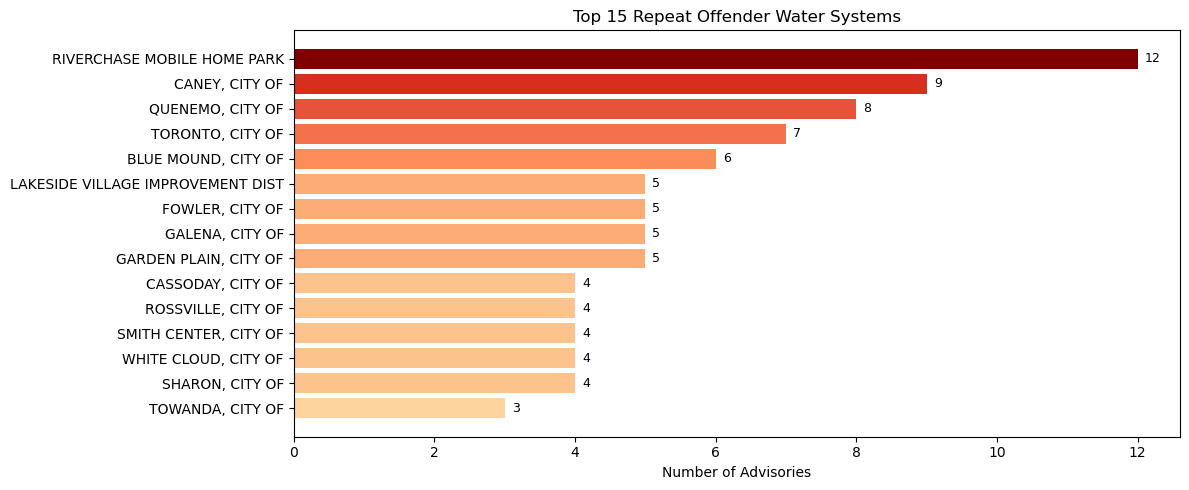

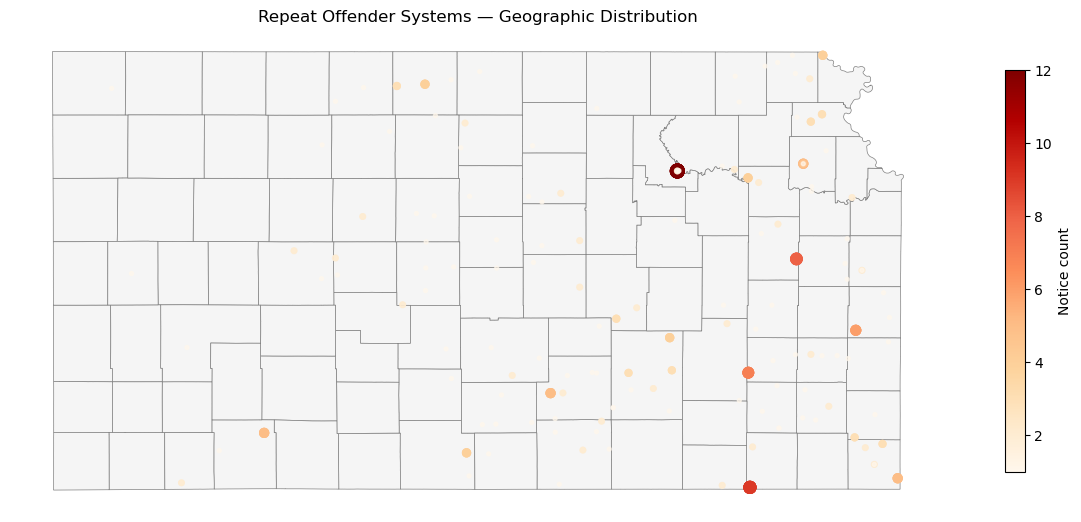


Top 10 repeat offenders:
                              PWS_Name      County  notice_count  \
112        RIVERCHASE MOBILE HOME PARK       Riley            12   
80                      CANEY, CITY OF  Montgomery             9   
92                    QUENEMO, CITY OF       Osage             8   
146                   TORONTO, CITY OF     Woodson             7   
66                 BLUE MOUND, CITY OF        Linn             6   
56   LAKESIDE VILLAGE IMPROVEMENT DIST   Jefferson             5   
74                     FOWLER, CITY OF       Meade             5   
30                     GALENA, CITY OF    Cherokee             5   
124              GARDEN PLAIN, CITY OF    Sedgwick             5   
19                   CASSODAY, CITY OF      Butler             4   

     total_duration  total_violations  
112              57               144  
80               63               990  
92               86                96  
146              33               294  
66               41      

In [22]:
repeat = (bwa_gdf.groupby(["Federal_ID", "PWS_Name", "County"])
          .agg(
              notice_count=("Advisory_Duration", "count"),
              total_duration=("Advisory_Duration", "sum"),
              avg_duration=("Advisory_Duration", "mean"),
              total_violations=("No._of_Violations", "sum"),
              total_severity=("severity_index", "sum")
          )
          .reset_index()
          .sort_values("notice_count", ascending=False))

# Bar chart of top repeat systems
fig, ax = plt.subplots(figsize=(12, 5))
top = repeat.head(15)
bars = ax.barh(top["PWS_Name"], top["notice_count"],
               color=plt.cm.OrRd(top["notice_count"] / top["notice_count"].max()))
ax.set_xlabel("Number of Advisories")
ax.set_title("Top 15 Repeat Offender Water Systems", fontsize=12)
ax.invert_yaxis()
for bar, val in zip(bars, top["notice_count"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Map repeat offenders by location
repeat_map = bwa_gdf.merge(
    repeat[["Federal_ID", "notice_count"]], on="Federal_ID", how="left"
)
fig, ax = plt.subplots(figsize=(12, 7))
ks_counties.plot(ax=ax, color="#f5f5f5", edgecolor="gray", linewidth=0.5)
repeat_map.plot(ax=ax, column="notice_count",
                cmap="OrRd", markersize=repeat_map["notice_count"] * 8,
                alpha=0.7, legend=True,
                legend_kwds={"label": "Notice count", "shrink": 0.6})
ax.set_title("Repeat Offender Systems — Geographic Distribution", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("\nTop 10 repeat offenders:")
print(repeat.head(10)[["PWS_Name","County","notice_count","total_duration","total_violations"]])